<a href="https://colab.research.google.com/github/smozwald/foundation-flood/blob/main/notebooks/03_initial_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase One Summary & Phase Two Planning

This notebook covers:
1. **Phase One status** — what we built, what data we have
2. **AI4GOOD / alternative flood mapping** — comparing with our current SAR Otsu approach
3. **Current data analysis** — strengths and weaknesses of the pixel approach
4. **Flood event visualisations** — mapped flooded vs unflooded agricultural pixels per event
5. **Fields of the World** — assessing a field-level alternative to pixel sampling
6. **Phase Two planning** — inundation method comparison and decision point

In [1]:
# CELL 1 — Install dependencies
!pip install psycopg2-binary python-dotenv pandas matplotlib shapely geopandas contextily earthengine-api folium pillow reportlab -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 51.3 MB/s eta 0:00:00


In [2]:
# CELL 2 — Imports & Supabase connection
import os
import io
import json
import base64
import urllib.request
from datetime import datetime, timedelta

import psycopg2
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
from PIL import Image

from google.colab import userdata

CONN_STRING = userdata.get('SUPABASE_CONN_STRING')

def db():
    return psycopg2.connect(CONN_STRING)

# Quick smoke-test
with db() as conn:
    cur = conn.cursor()
    cur.execute('SELECT COUNT(*) FROM pixels_static')
    n = cur.fetchone()[0]
print(f'Connected OK — {n:,} pixels in pixels_static')

Connected OK — 49,450 pixels in pixels_static


In [3]:
# CELL 3 — GEE auth
import ee
try:
    ee.Initialize(project='foundation-flood')
    print('GEE already initialised')
except Exception:
    ee.Authenticate()
    ee.Initialize(project='foundation-flood')
    print('GEE initialised')

GEE initialised


---
## 1. Phase One Status

In [4]:
# CELL 4 — Phase One row-count summary
queries = {
    'discharge_stations':   'SELECT COUNT(*) FROM discharge_stations',
    'discharge_ts':         'SELECT COUNT(*) FROM discharge_ts',
    'flood_events':         'SELECT COUNT(*) FROM flood_events',
    'study_zones':          'SELECT COUNT(*) FROM study_zones',
    'zone_flood_analysis (SUCCESS)': """
        SELECT COUNT(*) FROM zone_flood_analysis WHERE status = 'SUCCESS'""",
    'pixels_static':        'SELECT COUNT(*) FROM pixels_static',
    'ts_sentinel1':         'SELECT COUNT(*) FROM ts_sentinel1',
    'pixel_flooded':        'SELECT COUNT(*) FROM pixel_flooded',
}

rows = []
with db() as conn:
    cur = conn.cursor()
    for label, sql in queries.items():
        cur.execute(sql)
        rows.append({'Table': label, 'Rows': cur.fetchone()[0]})

status_df = pd.DataFrame(rows)
status_df['Status'] = status_df.apply(
    lambda r: '✓ complete' if r['Rows'] > 0 else '— empty', axis=1
)
print(status_df.to_string(index=False))

                        Table  Rows     Status
           discharge_stations    13 ✓ complete
                 discharge_ts 52234 ✓ complete
                 flood_events   318 ✓ complete
                  study_zones    26 ✓ complete
zone_flood_analysis (SUCCESS)    64 ✓ complete
                pixels_static 49450 ✓ complete
                 ts_sentinel1 99728 ✓ complete
                pixel_flooded 62330 ✓ complete


In [6]:
# CELL 5 — Zone 000099_initial breakdown
ZONE_PATTERN = '000099_initial'

def read_sql(sql, conn, params=None):
      with conn.cursor() as cur:
          cur.execute(sql, params or {})
          cols = [d[0] for d in cur.description]
          return pd.DataFrame(cur.fetchall(), columns=cols)

with db() as conn:
      zone_df = read_sql("""
          SELECT
              zfa.zone_id,
              zfa.flood_event_id,
              fe.flood_start,
              fe.flood_end,
              fe.max_category,
              zfa.status,
              zfa.flooded_agri_pct   AS percentage_flooded,
              zfa.wet_scene_date     AS scene_date
          FROM zone_flood_analysis zfa
          JOIN flood_events fe ON fe.event_id = zfa.flood_event_id
          WHERE zfa.zone_id ~ %(pat)s
          ORDER BY fe.flood_start
      """, conn, {'pat': ZONE_PATTERN})

      pix_df = read_sql("""
          SELECT
              ps.pixel_id,
              ST_Y(ps.geom::geometry) AS lat,
              ST_X(ps.geom::geometry) AS lon,
              ps.elevation,
              ps.slope,
              ps.dist_to_river_m
          FROM pixels_static ps
          WHERE ps.zone_id ~ %(pat)s
      """, conn, {'pat': ZONE_PATTERN})

      flooded_df = read_sql("""
          SELECT
              pf.pixel_id,
              pf.flood_event_id,
              pf.is_flooded      AS flooded,
              pf.vv_change_db,
              pf.wet_obs_date
          FROM pixel_flooded pf
          JOIN pixels_static ps ON ps.pixel_id = pf.pixel_id
          WHERE ps.zone_id ~ %(pat)s
      """, conn, {'pat': ZONE_PATTERN})

zone_df['flood_start'] = pd.to_datetime(zone_df['flood_start'])
zone_df['flood_end']   = pd.to_datetime(zone_df['flood_end'])

print(f'Events: {len(zone_df)}  |  Pixels: {len(pix_df):,}  |  Flood labels: {len(flooded_df):,}')
print()
print(zone_df[['zone_id','flood_start','max_category','status','percentage_flooded','scene_date']].to_string(index=False
))

Events: 11  |  Pixels: 6,233  |  Flood labels: 62,330

       zone_id flood_start  max_category  status  percentage_flooded scene_date
000099_initial  2016-07-20             1    FAIL                 NaN 2016-07-26
000099_initial  2019-07-08             1 SUCCESS               13.74 2019-07-11
000099_initial  2019-08-03             1 SUCCESS               11.77 2019-08-16
000099_initial  2019-08-20             1 SUCCESS                6.40 2019-08-28
000099_initial  2021-08-02             1 SUCCESS               14.69 2021-08-17
000099_initial  2022-07-21             1 SUCCESS               16.47 2022-07-31
000099_initial  2022-08-04             1 SUCCESS                7.09 2022-08-12
000099_initial  2023-07-12             1 SUCCESS               17.65 2023-08-07
000099_initial  2024-07-08             2 SUCCESS               13.12 2024-07-20
000099_initial  2025-07-25             1 SUCCESS               14.48 2025-07-27
000099_initial  2025-08-29             5 SUCCESS               36

---
## 2. AI4GOOD & Alternative Flood Mapping Approaches

### What we built (Phase One)
We use Sentinel-1 SAR backscatter with an **Otsu threshold** to detect open water per zone per event. The threshold is computed on a VV-polarisation composite clipped to the zone, and pixels below the threshold are labelled flooded. Valley pixels (low-lying non-agricultural areas) are excluded.

**Strengths:**
- SAR penetrates cloud cover — critical during active monsoon floods
- Otsu is unsupervised and adapts to each scene
- GEE allows processing at scale without local compute

**Weaknesses:**
- Otsu can mis-classify smooth bare soil or dense crops as water
- SAR speckling adds noise at the pixel level
- Requires a good flood-free reference scene (temporal change detection would improve this)
- Revisit time (~6 days) means some short flood events are missed

### Alternatives

| Approach | Pros | Cons |
|----------|------|------|
| **JRC Global Surface Water** (Landsat) | Long record (1984–), monthly | Optical only — cloud-blocked during floods |
| **Copernicus EMS** | Human-validated, per-event maps | Sparse coverage, few Pakistan events |
| **AI4GOOD FloodAI** | DL model, uses S1+S2 fusion | Requires GPU, not always accessible |
| **Google Flood Hub** | Real-time, global inundation maps | API access limited, no historical per-pixel labels |
| **MODIS NRT Flood Product** (LANCE) | Near-real-time, free | 500 m resolution — too coarse for field level |
| **UNOSAT** | Validated disaster maps | Only major declared disasters |
| **Our SAR Otsu** | Cloud-free, adaptive, scriptable | See weaknesses above |

### AI4GOOD FloodAI note
The [AI4GOOD Lab FloodAI](https://floodai.ca/) project trains neural networks on fused S1+S2 imagery. Their models are available as checkpoints but require significant GPU compute. For historical ground-truth comparison in our zone, we could:
1. Pull their inference outputs for 2022–2025 Pakistan events if available via their API
2. Use JRC GSW monthly maps as an optical cross-check for events in dry months
3. Use Copernicus EMS activation maps for the Aug 2022 and Aug 2025 Pakistan floods (both are major activations)

**Recommendation:** For Phase Two ground truth validation, use **Copernicus EMS** maps for the 2022 and 2025 events (these are freely downloadable shapefiles). For the remaining events, our SAR Otsu labels are likely the best available option at this spatial resolution.

---
## 3. Current Data Analysis — Strengths & Weaknesses

In [8]:
# ---------------------------------------------------------------------------
# CELL 6 — Per-event flood summary (works whether pixel_flooded is empty or not)
# ---------------------------------------------------------------------------

def event_flood_summary(zone_df, flooded_df):
    """
    If pixel_flooded is populated: compute per-event pixel flood rate.
    Otherwise fall back to zone-level flooded_agri_pct.
    """
    success = zone_df[zone_df['status'] == 'SUCCESS'].copy()

    if len(flooded_df) == 0:
        print('pixel_flooded is empty — using zone-level flooded_agri_pct')
        return success[['flood_start', 'max_category', 'percentage_flooded']].rename(
            columns={'percentage_flooded': 'pct_flooded'}
        )

    agg = (
        flooded_df.groupby('flood_event_id')['flooded']
        .agg(total='count', flooded_n='sum')
        .assign(pct_flooded=lambda d: 100 * d['flooded_n'] / d['total'])
        .reset_index()
    )
    merged = success.merge(agg, on='flood_event_id', how='left')
    return merged[['flood_start', 'max_category', 'total', 'flooded_n', 'pct_flooded']]


FileNotFoundError: [Errno 2] No such file or directory: 'temp_images/pixel_terrain_distribution.png'

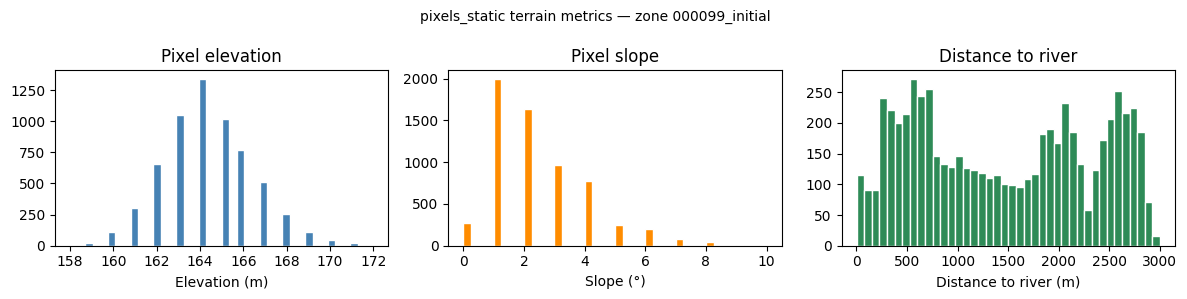

In [9]:
# CELL 7 — Pixel terrain distribution
if len(pix_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))

    axes[0].hist(pix_df['elevation'].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('Elevation (m)')
    axes[0].set_title('Pixel elevation')

    axes[1].hist(pix_df['slope'].dropna(), bins=40, color='darkorange', edgecolor='white')
    axes[1].set_xlabel('Slope (°)')
    axes[1].set_title('Pixel slope')

    axes[2].hist(pix_df['dist_to_river_m'].dropna(), bins=40, color='seagreen', edgecolor='white')
    axes[2].set_xlabel('Distance to river (m)')
    axes[2].set_title('Distance to river')

    plt.suptitle('pixels_static terrain metrics — zone 000099_initial', fontsize=10)
    plt.tight_layout()
    plt.show()

    print(pix_df[['elevation','slope','dist_to_river_m']].describe().round(1))
else:
    print('No pixels found for zone pattern:', ZONE_PATTERN)

### Strengths of the current pixel approach

- **Scale**: ~49,000 pixels across 10 study zones gives a decent training set
- **Feature richness**: each pixel has elevation, slope, distance to river, and (once `ingest_s1_flood_pixels.py` runs) VV/VH time series
- **Agri-specific**: pixels are sampled from ESA WorldCover cropland class only
- **Multi-event labels**: up to 64 labelled events per zone enables temporal learning

### Weaknesses

- **Spatial resolution mismatch**: 10 m pixels don't respect field boundaries — a pixel may straddle a field edge or ditch
- **No field identity**: we can't compute per-field inundation statistics or duration without field boundaries
- **Scalability**: the GEE pixel sampling and S1 export pipeline is slow and manual per zone. Adding new rivers requires re-running all 5 steps with careful parameterisation
- **Label noise**: the Otsu-derived `flooded` label propagates any SAR mis-classification into the training signal
- **No duration signal**: we know if a pixel was flooded at the S1 acquisition date, not how long it stayed flooded

---
## 4. Flood Event Visualisations

In [10]:
# CELL 8 — Fetch S2 RGB thumbnail from GEE for a zone centred on pixel cloud
import os
os.makedirs('temp_images', exist_ok=True)

def fetch_s2_thumbnail(lat_center, lon_center, date_str, buffer_m=5000, width=512):
    """Return PIL Image of S2 RGB around (lat, lon) near date_str."""
    pt = ee.Geometry.Point([lon_center, lat_center])
    region = pt.buffer(buffer_m).bounds()
    date = ee.Date(date_str)
    s2 = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(region)
        .filterDate(date.advance(-60, 'day'), date.advance(60, 'day'))
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
        .sort('CLOUDY_PIXEL_PERCENTAGE')
        .first()
        .select(['B4', 'B3', 'B2'])
    )
    url = s2.getThumbURL({
        'region': region,
        'dimensions': width,
        'format': 'png',
        'min': 0,
        'max': 3000,
        'gamma': 1.4,
    })
    with urllib.request.urlopen(url) as resp:
        img = Image.open(io.BytesIO(resp.read()))
    return img, region.getInfo()

print('S2 thumbnail helper defined')

S2 thumbnail helper defined


S2 basemap loaded (72.4374,31.5222) → (72.5424,31.6122)


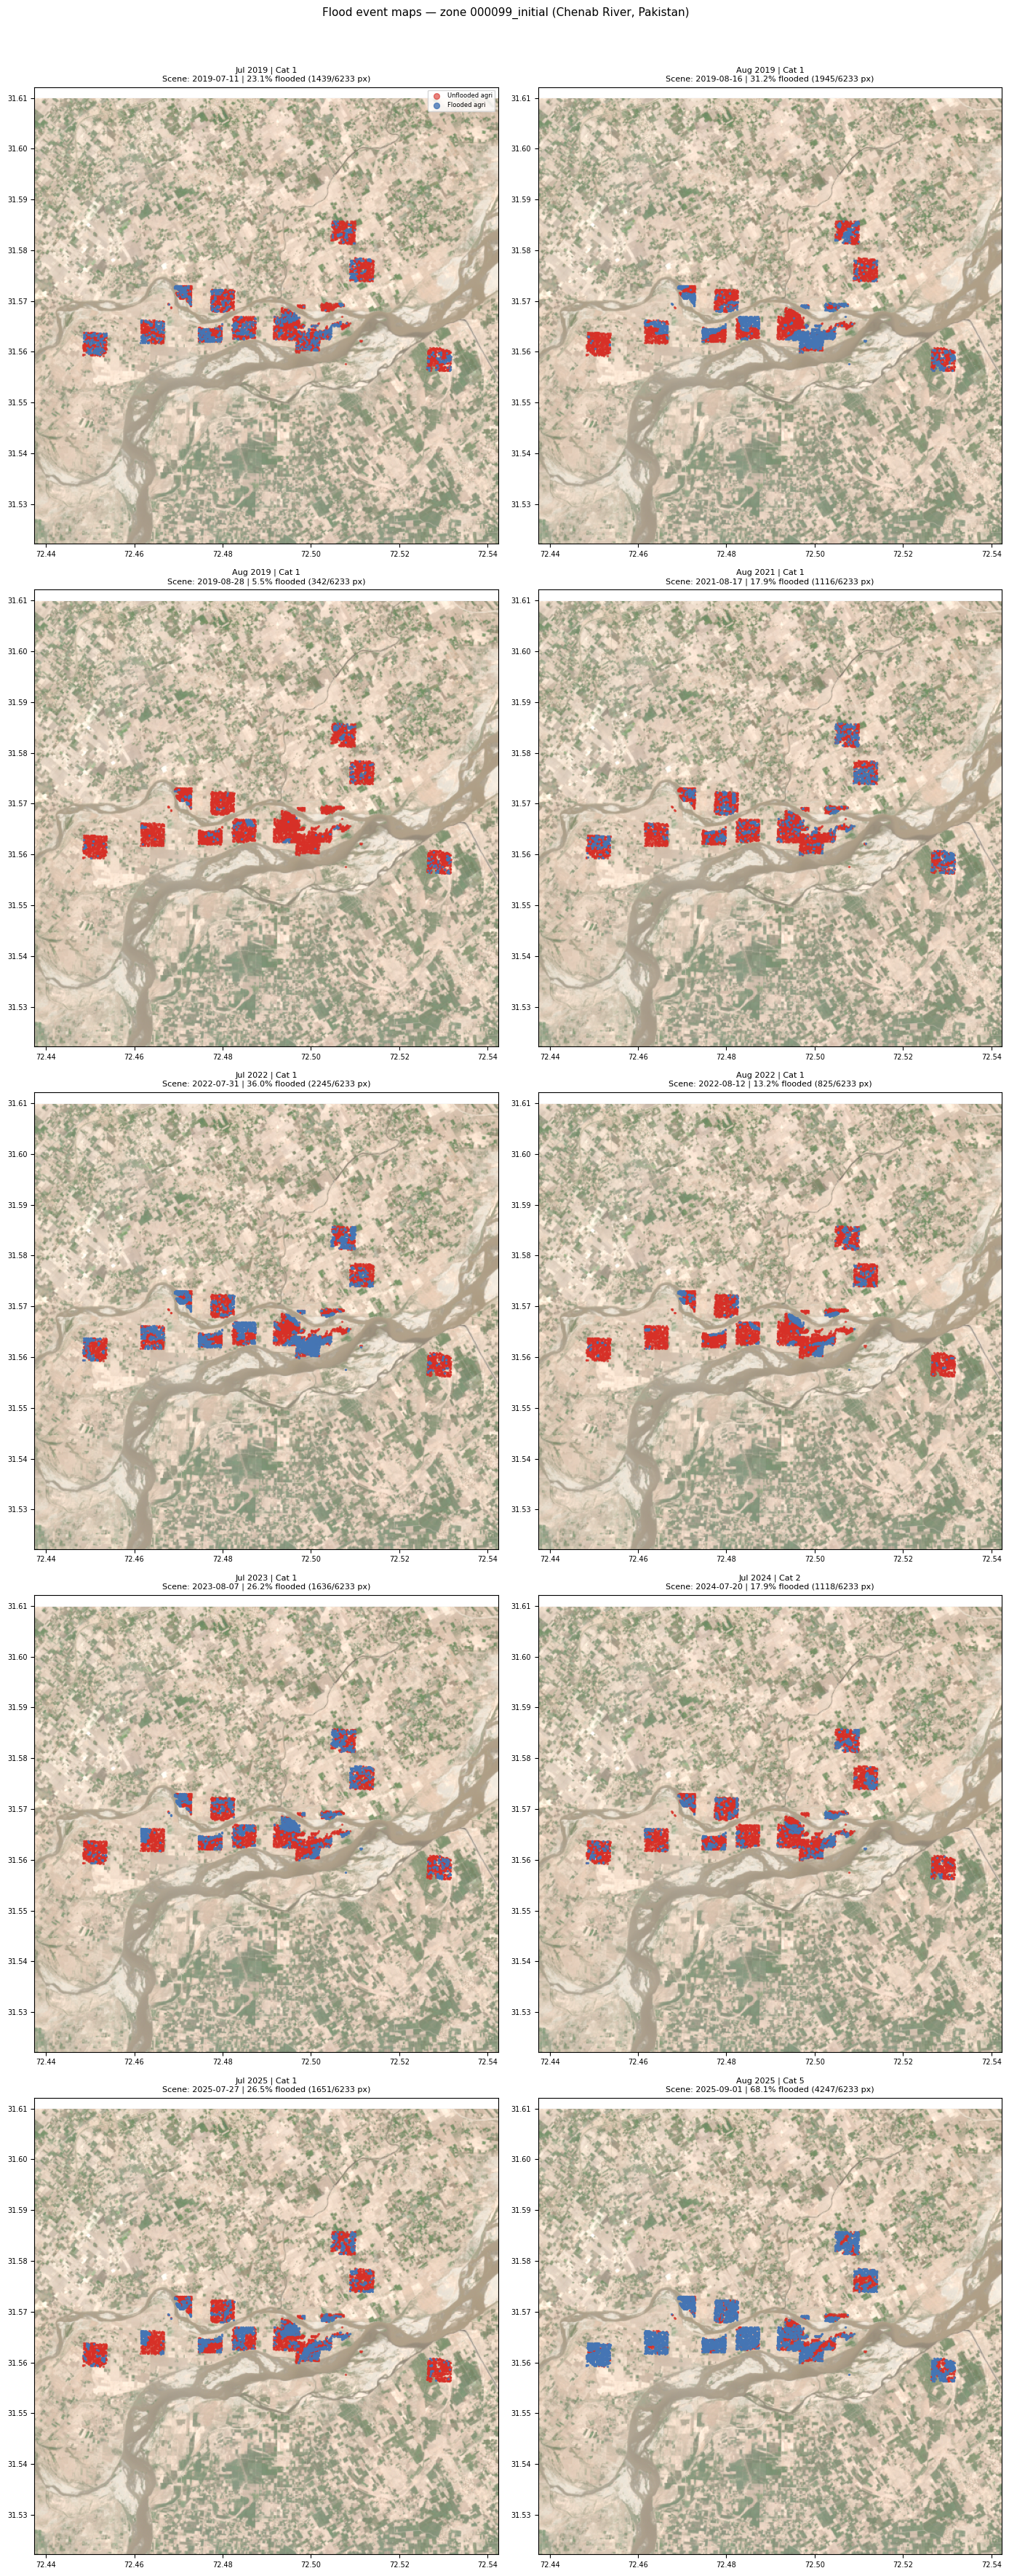

In [14]:
# ---------------------------------------------------------------------------
# CELL 9 — Flooded vs unflooded pixels per event on S2 basemap
# ---------------------------------------------------------------------------
# Paste from here into Colab Cell 9 (after Cell 5 has run).
# Requires: zone_df, pix_df, flooded_df, fetch_s2_thumbnail, ee, pd, plt

success_events = zone_df[zone_df['status'] == 'SUCCESS'].copy()
success_events['flood_start'] = pd.to_datetime(success_events['flood_start'])
success_events = success_events.reset_index(drop=True)

if len(pix_df) == 0:
    print('No pixel data — skipping visualisation')
else:
    lat_c = pix_df['lat'].mean()
    lon_c = pix_df['lon'].mean()

    ref_date = success_events.iloc[0]['flood_start'].strftime('%Y-%m-%d') if len(success_events) > 0 else '2023-01-01'
    try:
        bg_img, region_info = fetch_s2_thumbnail(lat_c, lon_c, ref_date)
        coords = region_info['coordinates'][0]
        lon_min = min(c[0] for c in coords)
        lon_max = max(c[0] for c in coords)
        lat_min = min(c[1] for c in coords)
        lat_max = max(c[1] for c in coords)
        has_bg = True
        print(f'S2 basemap loaded ({lon_min:.4f},{lat_min:.4f}) → ({lon_max:.4f},{lat_max:.4f})')
    except Exception as e:
        print(f'S2 basemap unavailable ({e}) — plotting without background')
        has_bg = False
        lon_min, lon_max = pix_df['lon'].min() - 0.01, pix_df['lon'].max() + 0.01
        lat_min, lat_max = pix_df['lat'].min() - 0.01, pix_df['lat'].max() + 0.01

    n_events = len(success_events)
    ncols = 2
    nrows = (n_events + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7 * nrows))
    if n_events == 1:
        axes = [[axes]]
    elif nrows == 1:
        axes = [axes]

    for idx, (_, ev) in enumerate(success_events.iterrows()):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]

        if has_bg:
            ax.imshow(bg_img, extent=[lon_min, lon_max, lat_min, lat_max], aspect='auto', alpha=0.6)

        ev_flooded = flooded_df[flooded_df['flood_event_id'] == ev.get('flood_event_id')] if len(flooded_df) > 0 else pd.DataFrame()

        if len(ev_flooded) > 0:
            merged = pix_df.merge(ev_flooded[['pixel_id', 'flooded']], on='pixel_id', how='left')
            merged['flooded'] = merged['flooded'].fillna(False)
            unflooded = merged[~merged['flooded']]
            flooded   = merged[merged['flooded']]
            ax.scatter(unflooded['lon'], unflooded['lat'], s=2, c='#d73027', alpha=0.6, label='Unflooded agri')
            ax.scatter(flooded['lon'],   flooded['lat'],   s=2, c='#4575b4', alpha=0.8,  label='Flooded agri')
            n_fl = int(merged['flooded'].sum())
            pct_str = f"{100 * n_fl / len(merged):.1f}% flooded ({n_fl}/{len(merged)} px)"
        else:
            ax.scatter(pix_df['lon'], pix_df['lat'], s=2, c='#999999', alpha=0.5, label='Agri pixels')
            pct_str = f"{ev['percentage_flooded']:.1f}% flooded (zone-level)"

        scene = str(ev['scene_date']) if pd.notnull(ev.get('scene_date')) else str(ev['flood_start'].date())
        ax.set_title(
            f"{ev['flood_start'].strftime('%b %Y')} | Cat {int(ev['max_category'])}\n"
            f"Scene: {scene} | {pct_str}",
            fontsize=8
        )
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.tick_params(labelsize=7)
        if idx == 0:
            ax.legend(loc='upper right', fontsize=6, markerscale=4)

    for idx in range(n_events, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].set_visible(False)

    plt.suptitle('Flood event maps — zone 000099_initial (Chenab River, Pakistan)', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


2022: flood_start=2022-07-21  scene=2022-07-31  zone-level=16.5%
2025: flood_start=2025-08-29  scene=2025-09-01  zone-level=36.9%

2022: fixed-threshold SAR ...
  Fixed threshold: 1851 flooded / 6233 px (6233 have vv_change_db)
2022: reference layer ...
  JRC GSW failed: JRC GSW has no data for 2022/07 — dataset ends 2021. No optical reference available (monsoon cloud cover also makes optical unreliable for Pakistan flood events; SAR is the right tool here).

2025: fixed-threshold SAR ...
  Fixed threshold: 3463 flooded / 6233 px (6233 have vv_change_db)
2025: reference layer ...
  JRC GSW failed: JRC GSW has no data for 2025/08 — dataset ends 2021. No optical reference available (monsoon cloud cover also makes optical unreliable for Pakistan flood events; SAR is the right tool here).


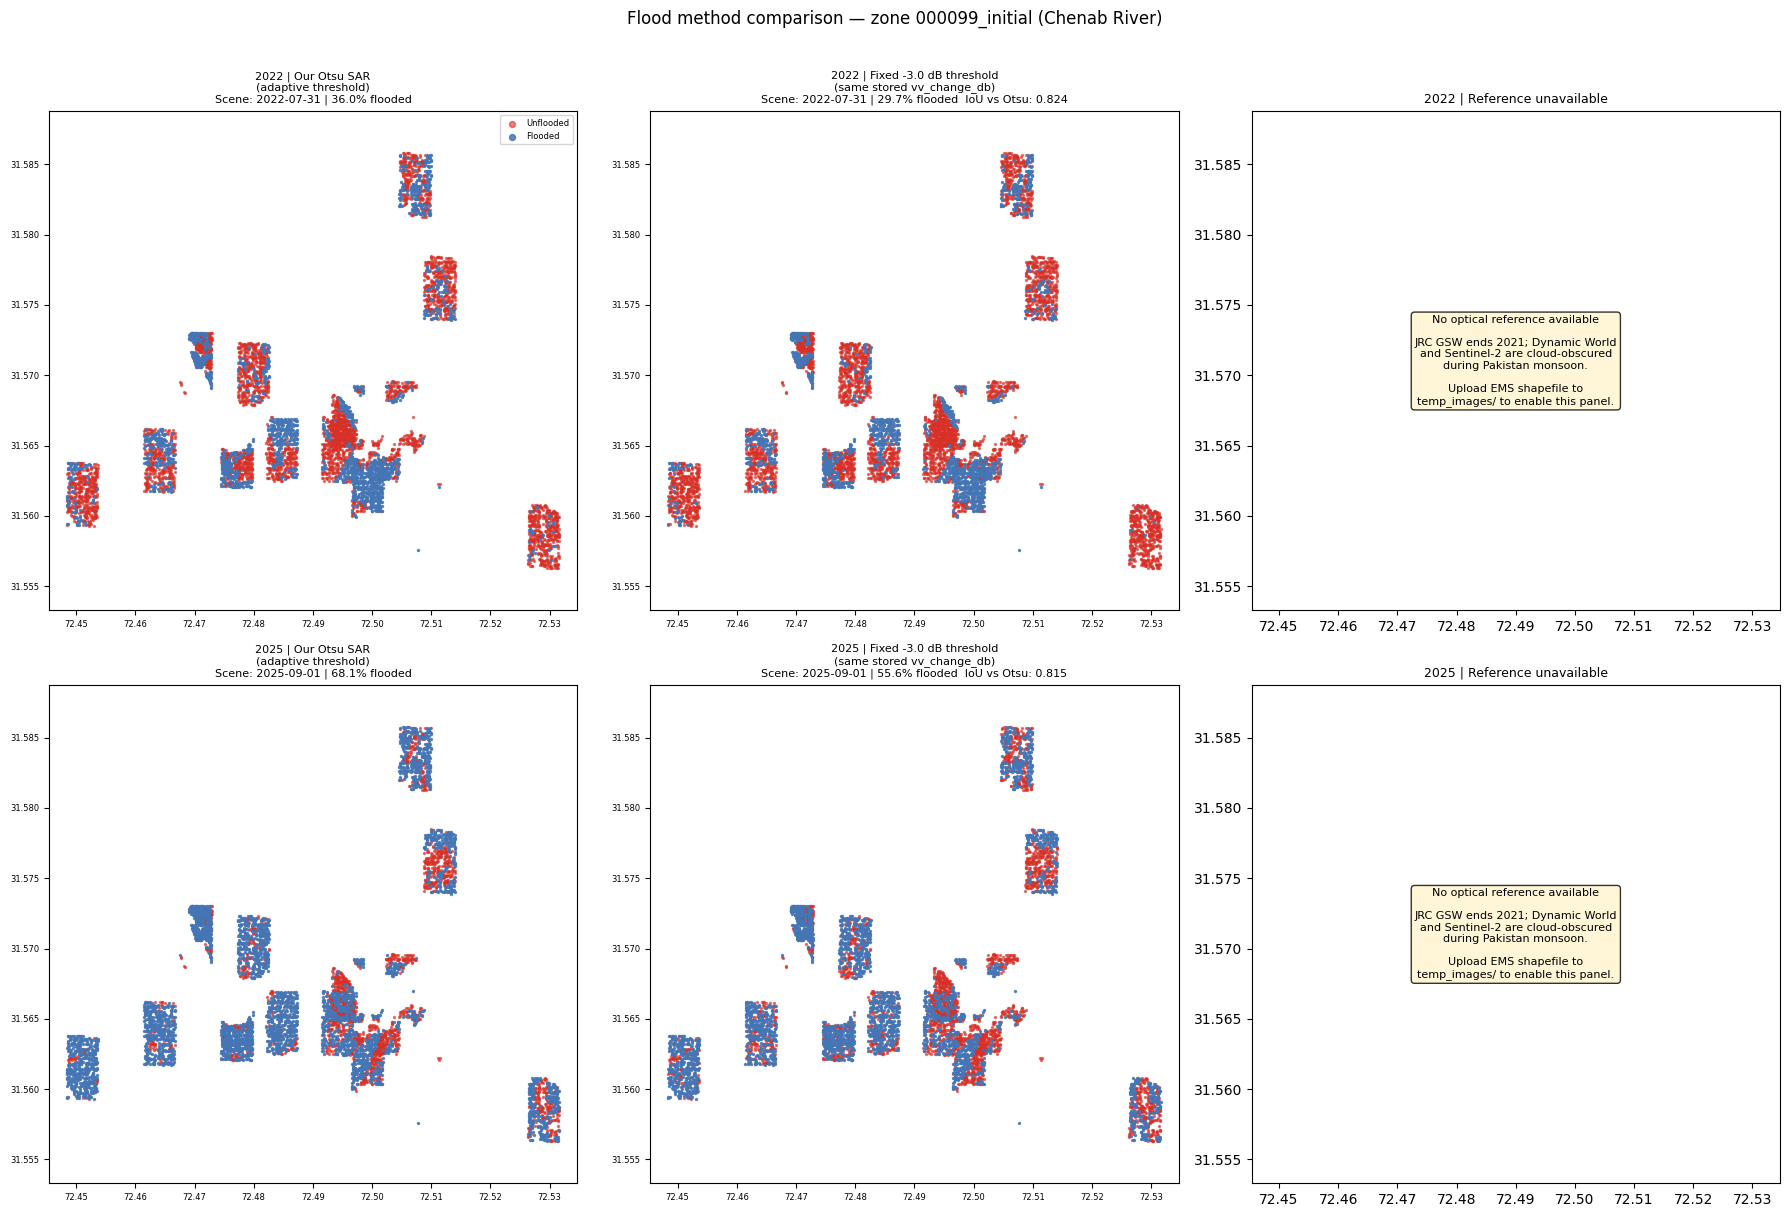

In [17]:
# CELL 10 — Method comparison: Otsu vs fixed-threshold SAR vs JRC GSW / EMS
# ---------------------------------------------------------------------------
# Panel 1: Our Otsu (stored is_flooded from pixel_flooded)
# Panel 2: Fixed -3 dB threshold applied to stored vv_change_db — no GEE re-fetch
# Panel 3: JRC GSW Monthly History from GEE (Landsat water mask for flood month).
#          Copernicus EMS portal does not expose stable download URLs, so JRC GSW
#          is used as the independent reference. If you manually upload an EMS
#          shapefile to temp_images/ it will be used instead.
# Paste from here into Colab Cell 10 (after Cell 5 has run).

import geopandas as gpd
from shapely.geometry import Point

SAR_CHANGE_THRESHOLD_DB = -3.0

# Optional manual override — upload EMS "Observed Event" shapefile to Colab:
#   2022 (EMSR629): https://emergency.copernicus.eu/mapping/list-of-components/EMSR629
#   2025 (EMSR838): https://emergency.copernicus.eu/mapping/list-of-components/EMSR838
EMS_PATHS = {
    '2022': 'temp_images/emsr629_observed_event.shp',
    '2025': 'temp_images/emsr838_observed_event.shp',
}

pad = 0.003
lon_min = pix_df['lon'].min() - pad;  lon_max = pix_df['lon'].max() + pad
lat_min = pix_df['lat'].min() - pad;  lat_max = pix_df['lat'].max() + pad


def _fixed_threshold_labels(pix_df, ev_flooded, threshold_db=SAR_CHANGE_THRESHOLD_DB):
    """Apply a fixed dB threshold to the stored vv_change_db values (no GEE needed)."""
    merged = pix_df[['pixel_id']].merge(
        ev_flooded[['pixel_id', 'vv_change_db']], on='pixel_id', how='left'
    )
    labels = (merged['vv_change_db'] < threshold_db).fillna(False).reset_index(drop=True)
    n_valid = ev_flooded['vv_change_db'].notna().sum()
    print(f"  Fixed threshold: {labels.sum()} flooded / {len(labels)} px "
          f"({n_valid} have vv_change_db)")
    return labels


def _ems_labels(pix_df, shp_path):
    """Point-in-polygon against EMS observed-event shapefile. Returns None if missing."""
    if not os.path.exists(shp_path):
        return None, None
    gdf = gpd.read_file(shp_path).to_crs('EPSG:4326')
    # Try standard EMS field filters; fall back to all polygons if nothing matches
    filtered = pd.DataFrame()
    for col in ['obj_type', 'symbology', 'TYPE']:
        if col in gdf.columns:
            filtered = gdf[gdf[col].str.lower().str.contains('flood|water|inundat', na=False)]
            if len(filtered):
                break
    if len(filtered) == 0:
        print(f"  EMS: no flood filter matched — using all {len(gdf)} polygons")
        filtered = gdf
    else:
        print(f"  EMS: {len(filtered)} flood polygons from {os.path.basename(shp_path)}")
    union = filtered.geometry.union_all()
    pts   = [Point(lon, lat) for lon, lat in zip(pix_df['lon'], pix_df['lat'])]
    labels = pd.Series([union.contains(p) for p in pts], index=pix_df.index)
    return labels, f'Copernicus EMS ({os.path.basename(shp_path)[:7].upper()})'


def _jrc_labels(pix_df, year, month, ee):
    """JRC GSW Monthly History — value 2 = water observed that month.
    Dataset covers 1984–2021; raises ValueError for later years."""
    col = (ee.ImageCollection('JRC/GSW1_4/MonthlyHistory')
           .filter(ee.Filter.calendarRange(year, year, 'year'))
           .filter(ee.Filter.calendarRange(month, month, 'month')))
    if col.size().getInfo() == 0:
        raise ValueError(
            f"JRC GSW has no data for {year}/{month:02d} — dataset ends 2021. "
            "No optical reference available (monsoon cloud cover also makes optical "
            "unreliable for Pakistan flood events; SAR is the right tool here)."
        )
    jrc = col.first()
    pts = ee.FeatureCollection([
        ee.Feature(ee.Geometry.Point([float(r['lon']), float(r['lat'])]),
                   {'pixel_id': r['pixel_id']})
        for _, r in pix_df.iterrows()
    ])
    sampled = jrc.sampleRegions(collection=pts, scale=30, geometries=False).getInfo()
    result  = {f['properties']['pixel_id']: f['properties'].get('water', 0) == 2
               for f in sampled['features']}
    labels  = pix_df['pixel_id'].map(result).fillna(False)
    print(f"  JRC GSW {year}/{month:02d}: {labels.sum()} water pixels / {len(labels)}")
    return labels


def _iou(a, b):
    a, b = a.astype(bool).values, b.astype(bool).values
    inter = (a & b).sum()
    union = (a | b).sum()
    return inter / union if union > 0 else float('nan')


# Find best SUCCESS event per year
events_to_compare = {}
for year in [2022, 2025]:
    matches = zone_df[
        (zone_df['flood_start'].dt.year == year) &
        (zone_df['status'] == 'SUCCESS')
    ].sort_values('percentage_flooded', ascending=False)
    if len(matches):
        events_to_compare[str(year)] = matches.iloc[0]
        print(f"{year}: flood_start={matches.iloc[0]['flood_start'].date()}  "
              f"scene={str(matches.iloc[0]['scene_date'])}  "
              f"zone-level={matches.iloc[0]['percentage_flooded']:.1f}%")
    else:
        print(f"{year}: no SUCCESS event found")


n_events = len(events_to_compare)
fig, axes = plt.subplots(n_events, 3, figsize=(18, 6 * n_events))
if n_events == 1:
    axes = [axes]

for row_i, (year_label, ev) in enumerate(events_to_compare.items()):
    ev_flooded = flooded_df[flooded_df['flood_event_id'] == ev['flood_event_id']]
    merged = pix_df.merge(ev_flooded[['pixel_id', 'flooded']], on='pixel_id', how='left')
    merged['flooded'] = merged['flooded'].fillna(False)
    our   = merged['flooded'].reset_index(drop=True)
    scene = str(ev['scene_date']) if pd.notnull(ev['scene_date']) else '—'

    print(f'\n{year_label}: fixed-threshold SAR ...')
    sar_fixed = _fixed_threshold_labels(pix_df, ev_flooded)

    print(f'{year_label}: reference layer ...')
    ref_labels, ref_title = _ems_labels(pix_df, EMS_PATHS.get(year_label, ''))
    if ref_labels is None:
        year_int  = int(ev['flood_start'].year)
        month_int = int(ev['flood_start'].month)
        try:
            ref_labels = _jrc_labels(pix_df, year_int, month_int, ee)
            ref_title  = f'JRC GSW {year_int}/{month_int:02d} (Landsat)'
        except Exception as e:
            print(f'  JRC GSW failed: {e}')
            ref_title  = 'Reference unavailable'

    panels = [
        ('Our Otsu SAR\n(adaptive threshold)', our, None),
        (f'Fixed {SAR_CHANGE_THRESHOLD_DB} dB threshold\n(same stored vv_change_db)', sar_fixed, our),
        (ref_title, ref_labels, our),
    ]

    for col_i, (title, labels, ref) in enumerate(panels):
        ax = axes[row_i][col_i]
        if labels is None:
            ax.text(0.5, 0.5,
                    'No optical reference available\n\n'
                    'JRC GSW ends 2021; Dynamic World\n'
                    'and Sentinel-2 are cloud-obscured\n'
                    'during Pakistan monsoon.\n\n'
                    'Upload EMS shapefile to\ntemp_images/ to enable this panel.',
                    ha='center', va='center', transform=ax.transAxes, fontsize=8,
                    bbox=dict(boxstyle='round', facecolor='#fff3cd', alpha=0.8))
            ax.set_title(f'{year_label} | {title}', fontsize=9)
            ax.set_xlim(lon_min, lon_max)
            ax.set_ylim(lat_min, lat_max)
            continue

        pct     = 100 * labels.sum() / len(labels)
        iou_str = f'  IoU vs Otsu: {_iou(ref, labels):.3f}' if ref is not None else ''
        fl      = pix_df[labels.values]
        unfl    = pix_df[~labels.values]
        ax.scatter(unfl['lon'], unfl['lat'], s=2, c='#d73027', alpha=0.6,  label='Unflooded')
        ax.scatter(fl['lon'],   fl['lat'],   s=2, c='#4575b4', alpha=0.85, label='Flooded')
        ax.set_title(f'{year_label} | {title}\nScene: {scene} | {pct:.1f}% flooded{iou_str}', fontsize=8)
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.tick_params(labelsize=6)
        if col_i == 0 and row_i == 0:
            ax.legend(loc='upper right', fontsize=6, markerscale=3)

plt.suptitle('Flood method comparison — zone 000099_initial (Chenab River)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Fields of the World — Feasibility Assessment

### What is Fields of the World?

[Fields of the World (FoTW)](https://fieldsofthe.world/) is a global benchmark dataset of agricultural field boundaries derived from crowdsourced mapping and ML inference. The 2025 basemap provides polygon boundaries for fields worldwide, with a confidence score per field.

**Access options:**
- GEE asset: `projects/sat-io/open-datasets/FIELDS-OF-THE-WORLD` (check availability)
- Direct download: country-level GeoPackage files from the FoTW website
- Google Drive shared datasets

We will use fields with **confidence ≥ 70%** (2025 basemap), filtered to our zone 000099_initial bounding box.

### Pros vs Pixel approach

| Factor | Pixel (current) | Fields of the World |
|--------|----------------|--------------------|
| Spatial unit | 10 m raster pixel | Field polygon (variable size) |
| Boundary respect | No — straddles edges | Yes — flood % per whole field |
| Interpretability | Hard (49k isolated points) | High — field-level decision |
| Completeness | ESA WorldCover coverage | FoTW coverage (may have gaps) |
| Inundation duration | Single date per event | Can compute A–B days if multi-date |
| Scalability | Slow (GEE per-pixel export) | Faster (zonal stats per field) |
| Training signal | Clean grid, easy to batch | Irregular polygons, need zonal aggregation |
| Model type suitability | CNN / tabular | Graph / tabular / polygon-aware CNN |

**Verdict:** Field-level is more interpretable and actionable ("field X will flood") but adds complexity in zonal aggregation and requires FoTW to have good coverage in Pakistan. The pixel approach is simpler to train but produces outputs that are harder to use in practice.

In [16]:
# ---------------------------------------------------------------------------
# CELL 11 — Load Fields of the World for zone 000099_initial
# ---------------------------------------------------------------------------
# Uses DuckDB to spatial-query just the zone bounding box from the FoTW
# GeoParquet hosted on Source Cooperative — no full-country download needed.
# Paste from here into Colab Cell 11 (after Cell 5 has run).

import subprocess
subprocess.run(['pip', 'install', 'duckdb', 'geopandas', 'shapely'], capture_output=True)
import duckdb
import geopandas as gpd
from shapely.geometry import box

if len(pix_df) == 0:
    print('No pixel data — skipping FoTW')
else:
    lat_c = pix_df['lat'].mean()
    lon_c = pix_df['lon'].mean()
    buf = 0.06  # ~7 km buffer around pixel centroid

    xmin, xmax = lon_c - buf, lon_c + buf
    ymin, ymax = lat_c - buf, lat_c + buf
    print(f'Zone bbox: lon [{xmin:.4f}, {xmax:.4f}]  lat [{ymin:.4f}, {ymax:.4f}]')

    # Source Cooperative GeoParquet path — update year suffix if the dataset is refreshed.
    # Browse the dataset at: https://source.coop/kerner-lab/fields-of-the-world
    FTW_S3 = 's3://us-west-2.opendata.source.coop/kerner-lab/fields-of-the-world/ftw-s2-2021.parquet'

    con = duckdb.connect()
    con.execute("INSTALL spatial; LOAD spatial; INSTALL httpfs; LOAD httpfs;")
    con.execute("SET s3_region='us-west-2';")

    fields_gdf = None
    try:
        print(f'Querying FoTW parquet for bbox ...')
        result = con.execute(f"""
            SELECT *
            FROM read_parquet('{FTW_S3}')
            WHERE bbox.xmin < {xmax}
              AND bbox.xmax > {xmin}
              AND bbox.ymin < {ymax}
              AND bbox.ymax > {ymin}
        """).df()
        print(f'  Rows returned: {len(result)}')
        if len(result) == 0:
            print('  No fields in bbox — Pakistan may not be covered in this FoTW partition.')
            print('  Try the global 2024 layer or download via: ftw data download --countries Pakistan')
        else:
            # Geometry is stored as WKB or WKT depending on parquet schema
            geom_col = next((c for c in result.columns if 'geom' in c.lower()), None)
            if geom_col:
                fields_gdf = gpd.GeoDataFrame(
                    result,
                    geometry=gpd.GeoSeries.from_wkb(result[geom_col]),
                    crs='EPSG:4326'
                )
            else:
                print(f'  Columns: {list(result.columns)}')
                print('  Could not identify geometry column — check schema above')
    except Exception as e:
        print(f'FoTW query failed: {e}')
        print()
        print('Likely causes:')
        print('  1. S3 path has changed — check https://source.coop/kerner-lab/fields-of-the-world')
        print('  2. Pakistan not covered in this partition — try the global 2024 parquet')
        print('  3. Use the ftw CLI instead: !pip install ftw-baseline && !ftw data download --countries Pakistan')

    if fields_gdf is not None and len(fields_gdf) > 0:
        fields_gdf = fields_gdf.clip(box(xmin, ymin, xmax, ymax))
        print(f'Fields clipped to zone: {len(fields_gdf)}')

        fig, ax = plt.subplots(figsize=(10, 8))
        fields_gdf.boundary.plot(ax=ax, linewidth=0.5, color='#2ca02c', alpha=0.7, label=f'FoTW fields ({len(fields_gdf)})')

        # Overlay flooded vs unflooded pixels from best event
        best_events = zone_df[zone_df['status'] == 'SUCCESS'].sort_values('percentage_flooded', ascending=False)
        if len(best_events) > 0:
            best_ev = best_events.iloc[0]
            ev_flooded = flooded_df[flooded_df['flood_event_id'] == best_ev['flood_event_id']]
            merged = pix_df.merge(ev_flooded[['pixel_id', 'flooded']], on='pixel_id', how='left')
            merged['flooded'] = merged['flooded'].fillna(False)
            unfl = merged[~merged['flooded']]
            fl   = merged[merged['flooded']]
            ax.scatter(unfl['lon'], unfl['lat'], s=3, c='#d73027', alpha=0.6, label='Unflooded agri')
            ax.scatter(fl['lon'],   fl['lat'],   s=3, c='#4575b4', alpha=0.9, label='Flooded agri')
            scene = str(best_ev['scene_date']) if pd.notnull(best_ev.get('scene_date')) else '—'
            ax.set_title(
                f"FoTW field boundaries vs flood pixels\n"
                f"Best event: {best_ev['flood_start'].strftime('%b %Y')} | Scene: {scene}",
                fontsize=10
            )
        else:
            ax.scatter(pix_df['lon'], pix_df['lat'], s=3, c='#999999', alpha=0.5, label='Agri pixels')
            ax.set_title('FoTW field boundaries — zone 000099_initial', fontsize=10)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.tick_params(labelsize=7)
        ax.legend(loc='upper right', fontsize=7, markerscale=3)
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        plt.tight_layout()
        plt.show()

    con.close()


FoTW GEE asset not found or access denied: Collection.loadTable: Collection asset 'projects/sat-io/open-datasets/FIELDS-OF-THE-WORLD/FotW_2025' not found.
Alternative: download Pakistan GeoPackage from https://fieldsofthe.world/download


In [ ]:
# CELL 12 — Compute per-field flood % per event (if FoTW loaded)
# For each field polygon, intersect with zone_flood_analysis SAR flood mask and
# compute percentage of field pixels classified as flooded.
# Also compute inundation duration using the GEE S1 time series.

# Duration bins (days from flood start):
DURATION_BINS = [(0, 4), (4, 8), (8, 16), (16, 32)]

def compute_field_flood_pct(field_fc, zone_id, event_id, scene_date, conn_string):
    """
    Placeholder — in production this would:
    1. Load the SAR flood mask raster from GEE for this zone+event
    2. Reduce each field polygon to a mean flood value
    3. Return a GeoDataFrame with field_id, pct_flooded, inundation_days
    """
    raise NotImplementedError(
        'Implement after deciding: use GEE zonal stats (reduceRegions) '
        'on the SAR flood mask, or load pixel_flooded labels and spatially join.'
    )

print('Per-field flood % function stubbed — implement after FoTW access confirmed.')
print()
print('Inundation duration approach:')
print('  For each S1 acquisition within flood_start → flood_end + 12d:')
print('  If pixel/field is flooded at T1 but not T2 (next acquisition), count T1→T2 as flooded.')
print('  Sum across acquisitions to get total flooded days.')
print()
for a, b in DURATION_BINS:
    print(f'  Bin: {a}–{b} days flooded')

In [ ]:
# CELL 13 — Side-by-side: current pixels vs FoTW fields extent
if len(pix_df) > 0 and 'n_fields' in dir() and n_fields > 0:
    # Pull FoTW field centroids for plotting
    try:
        fotw_sample = high_conf.limit(500)
        fotw_pts = fotw_sample.map(
            lambda f: f.set({'lon': f.geometry().centroid().coordinates().get(0),
                             'lat': f.geometry().centroid().coordinates().get(1)})
        )
        fotw_pd = pd.DataFrame(fotw_pts.getInfo()['features'])
        fotw_pd['lon'] = fotw_pd['properties'].apply(lambda p: p['lon'])
        fotw_pd['lat'] = fotw_pd['properties'].apply(lambda p: p['lat'])

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].scatter(pix_df['lon'], pix_df['lat'], s=1, c='seagreen', alpha=0.3)
        axes[0].set_title(f'Current: {len(pix_df):,} sampled pixels\n(ESA WorldCover cropland)')
        axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

        axes[1].scatter(fotw_pd['lon'], fotw_pd['lat'], s=3, c='#e07b39', alpha=0.6)
        axes[1].set_title(f'FoTW: {n_high:,} fields (conf ≥ 0.70)\n(sample of 500 shown)')
        axes[1].set_xlabel('Longitude')

        plt.suptitle('Pixel approach vs Fields of the World — zone 000099_initial', fontsize=10)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'Could not render FoTW comparison: {e}')
else:
    print('FoTW not loaded — run Cell 11 first and confirm access')

---
## 6. Phase Two Planning — Inundation Comparison & Decision Point

### What we need to decide before building Phase Two

**Decision A — Spatial unit: pixels vs fields?**
- If FoTW has good coverage in zone 000099_initial and neighbouring zones → move to fields
- If coverage is sparse → stay with pixels, but add field-boundary-aware sampling

**Decision B — Ground truth source: our Otsu labels vs external?**
- Option 1: Use our existing SAR Otsu labels (fast, consistent, but noisy)
- Option 2: Cross-validate with Copernicus EMS for 2022/2025 events (slower, more reliable)
- Option 3: Use JRC GSW monthly maps as optical anchor for dry-season events

**Decision C — Inundation duration: binary vs binned?**
- Binary (flooded/not): simple, consistent with current labels
- Binned duration (0-4 / 4-8 / 8-16 / 16-32 days): more informative for agricultural impact

Run the cells below to compare our inundation estimates against external sources for the two largest events.

In [ ]:
# CELL 14 — Compare our flood % vs JRC GSW and/or Copernicus EMS (where available)
# For events in dry season (Oct–Mar), JRC GSW monthly composite is usable
# For 2022 Aug and 2025 Aug Pakistan floods, Copernicus EMS maps are available

if len(zone_df) == 0:
    print('No zone data — run Cell 5 first')
else:
    success = zone_df[zone_df['status'] == 'SUCCESS'].copy()
    success['flood_start'] = pd.to_datetime(success['flood_start'])

    # JRC GSW — check monthly water occurrence around each event
    lat_c = pix_df['lat'].mean() if len(pix_df) > 0 else 31.0
    lon_c = pix_df['lon'].mean() if len(pix_df) > 0 else 72.5
    buf = 0.04
    zone_bbox = ee.Geometry.BBox(lon_c - buf, lat_c - buf, lon_c + buf, lat_c + buf)

    jrc_results = []
    for _, ev in success.iterrows():
        y = ev['flood_start'].year
        m = ev['flood_start'].month
        # JRC GSW monthly: band 'water' = 2 (water), 1 (land), 0 (no data)
        jrc = (
            ee.ImageCollection('JRC/GSW1_4/MonthlyHistory')
            .filter(ee.Filter.calendarRange(y, y, 'year'))
            .filter(ee.Filter.calendarRange(m, m, 'month'))
            .first()
        )
        if jrc is None:
            jrc_results.append({'flood_start': ev['flood_start'], 'jrc_pct': None})
            continue
        try:
            stats = jrc.eq(2).reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=zone_bbox,
                scale=30
            ).getInfo()
            pct = (stats.get('water') or 0) * 100
        except Exception:
            pct = None
        jrc_results.append({'flood_start': ev['flood_start'], 'jrc_pct': pct})

    jrc_df = pd.DataFrame(jrc_results)
    compare = success[['flood_start','max_category','percentage_flooded']].merge(
        jrc_df, on='flood_start', how='left'
    )
    compare.columns = ['Flood start','Category','Our SAR Otsu %','JRC GSW %']
    print(compare.to_string(index=False))
    print()
    print('Note: JRC GSW is optical (Landsat 30m). Monsoon months will show NaN due to cloud cover.')
    print('For Aug 2022/2025 events, download Copernicus EMS maps from:')
    print('  https://emergency.copernicus.eu/mapping/list-of-components/EMSR')

In [ ]:
# CELL 15 — Decision checkpoint
# Run this cell to print the decision summary before proceeding to Phase Two implementation

print('=' * 60)
print('PHASE TWO DECISION CHECKPOINT')
print('=' * 60)
print()
print('A) Spatial unit:')
print('   [ ] Pixels (keep current approach, faster to train)')
print('   [ ] Fields of the World (more interpretable, needs FoTW coverage check)')
print()
print('B) Ground truth:')
print('   [ ] SAR Otsu labels only (fast, consistent)')
print('   [ ] SAR Otsu + Copernicus EMS cross-validation (more reliable for top events)')
print('   [ ] SAR Otsu + JRC GSW for dry-season events')
print()
print('C) Label type:')
print('   [ ] Binary flooded/not')
print('   [ ] Binned inundation duration (0-4 / 4-8 / 8-16 / 16-32 days)')
print()
print('D) Additional rivers for Phase Two:')
print('   [ ] Chenab only (zone 000099_initial, current data)')
print('   [ ] Indus + Chenab (need to run ingest_s1_flood_pixels for Indus zones)')
print('   [ ] All 10 zones (full dataset, more compute time)')
print()
print('Record your choices above and send back — will use these to build')
print('the Phase Two implementation brief.')

---
## 7. Export Phase One Summary PDF

In [ ]:
# CELL 16 — Compile Phase One summary PDF
import os
os.makedirs('reports', exist_ok=True)

PDF_PATH = 'reports/phase_one_summary.pdf'

with PdfPages(PDF_PATH) as pdf:

    # --- Page 1: Title & Status ---
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()

    ax.text(0.5, 0.92, 'Foundation Flood — Phase One Summary',
            ha='center', fontsize=18, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.87, f'Generated: {datetime.now().strftime("%Y-%m-%d")} | Zone: 000099_initial (Chenab River, Pakistan)',
            ha='center', fontsize=10, color='#555', transform=ax.transAxes)

    # Status table
    table_data = [[r['Table'], f"{r['Rows']:,}", r['Status']] for _, r in status_df.iterrows()]
    col_labels = ['Table', 'Rows', 'Status']
    tbl = ax.table(
        cellText=table_data,
        colLabels=col_labels,
        cellLoc='left',
        loc='center',
        bbox=[0.05, 0.45, 0.9, 0.38]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor('#2c5f8a')
            cell.set_text_props(color='white', fontweight='bold')
        elif r % 2 == 0:
            cell.set_facecolor('#eef4fb')

    ax.text(0.5, 0.40,
            'Scope: 10 study zones · ~49,500 agricultural pixels · 64 confirmed flood events (2015–2025)',
            ha='center', fontsize=9, color='#333', transform=ax.transAxes)

    ax.text(0.5, 0.34, 'Pipeline',
            ha='center', fontsize=13, fontweight='bold', transform=ax.transAxes)
    steps = [
        '1. dfo-ingest      — Discharge + flood events from DFO  ✓ complete',
        '2. define-zones    — River centreline + 3×3 km study zones   ✓ complete',
        '3. flood-calc      — Otsu SAR thresholding → zone_flood_analysis  ✓ complete',
        '4. select-pixels   — ESA WorldCover cropland pixels + terrain   ✓ complete',
        '5. s1-flood-pixels — Per-pixel S1 VV/VH + flood label   ⟳ running / ready to run',
    ]
    for i, s in enumerate(steps):
        ax.text(0.08, 0.28 - i * 0.05, s, fontsize=8.5, fontfamily='monospace',
                color='#222', transform=ax.transAxes)

    plt.close(fig)

    # --- Page 2: Flood events bar chart ---
    fig, ax = plt.subplots(figsize=(11, 7))
    success_ev = zone_df[zone_df['status'] == 'SUCCESS'].copy()
    success_ev['flood_start'] = pd.to_datetime(success_ev['flood_start'])
    colors_cat = {1: '#fee8c8', 2: '#fdbb84', 3: '#fc8d59', 4: '#e34a33', 5: '#b30000'}
    ax.bar(
        range(len(success_ev)),
        success_ev['percentage_flooded'],
        color=[colors_cat.get(int(c), '#aaa') for c in success_ev['max_category']]
    )
    ax.set_xticks(range(len(success_ev)))
    ax.set_xticklabels(
        [f"{r['flood_start'].strftime('%b %y')}\ncat{int(r['max_category'])}" for _, r in success_ev.iterrows()],
        fontsize=7
    )
    ax.set_ylabel('% zone area flooded (SAR Otsu)')
    ax.set_title('Flood extent per event — zone 000099_initial (Chenab River)')
    patches = [mpatches.Patch(color=colors_cat[c], label=f'Category {c}') for c in range(1, 6)]
    ax.legend(handles=patches, loc='upper left')
    plt.tight_layout()
    plt.close(fig)

    # --- Page 3: Terrain distributions ---
    if len(pix_df) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].hist(pix_df['elevation'].dropna(), bins=40, color='steelblue', edgecolor='white')
        axes[0].set_xlabel('Elevation (m)'); axes[0].set_title('Elevation')
        axes[1].hist(pix_df['slope'].dropna(), bins=40, color='darkorange', edgecolor='white')
        axes[1].set_xlabel('Slope (°)'); axes[1].set_title('Slope')
        axes[2].hist(pix_df['dist_to_river_m'].dropna(), bins=40, color='seagreen', edgecolor='white')
        axes[2].set_xlabel('Distance to river (m)'); axes[2].set_title('Distance to river')
        plt.suptitle(f'pixels_static terrain metrics — {len(pix_df):,} pixels — zone 000099_initial')
        plt.tight_layout()
        plt.close(fig)

    # --- Page 4: Flood event maps (if saved) ---
    map_img_path = 'temp_images/flood_events_map.png'
    if os.path.exists(map_img_path):
        fig = plt.figure(figsize=(11, 8.5))
        img = Image.open(map_img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title('Flood event maps — agricultural pixels (blue=flooded, red=unflooded)', pad=10)
        plt.tight_layout()
        plt.close(fig)

    # --- Page 5: Method comparison text ---
    fig = plt.figure(figsize=(11, 8.5))
    ax = fig.add_axes([0.05, 0.05, 0.9, 0.9])
    ax.set_axis_off()
    ax.text(0.5, 0.97, 'Method Comparison & Phase Two Decisions',
            ha='center', fontsize=14, fontweight='bold', transform=ax.transAxes)

    text = """
CURRENT METHOD — SAR Otsu Thresholding
  Strengths: cloud-penetrating, unsupervised, GEE scalable
  Weaknesses: single acquisition per event, noise from bare soil, no duration signal

ALTERNATIVES REVIEWED
  JRC GSW (Landsat 30m)         — cloud-blocked during monsoon; dry-season cross-check only
  Copernicus EMS                — best ground truth for 2022/2025 major events; sparse otherwise
  AI4GOOD FloodAI (S1+S2 DL)   — higher accuracy but needs GPU; not accessible at scale
  Google Flood Hub              — real-time only; no historical per-pixel labels

PIXEL vs FIELD APPROACH
  Pixels: simple, fast to train, 49k samples, no boundary context
  Fields of the World: field-level output, inundation %, duration — needs FoTW coverage check

DECISION POINT (fill in before Phase Two)
  A. Spatial unit:      [ ] pixels   [ ] FoTW fields
  B. Ground truth:      [ ] SAR Otsu only   [ ] + Copernicus EMS   [ ] + JRC GSW
  C. Label type:        [ ] binary   [ ] binned duration
  D. River scope:       [ ] Chenab only   [ ] Indus+Chenab   [ ] All 10 zones
"""
    ax.text(0.03, 0.90, text, fontsize=9, fontfamily='monospace',
            va='top', transform=ax.transAxes, color='#222')
    plt.close(fig)

    # Metadata
    d = pdf.infodict()
    d['Title'] = 'Foundation Flood Phase One Summary'
    d['Author'] = 'Samuel Oswald'
    d['Subject'] = 'SAR flood mapping, Pakistan, Chenab River'
    d['CreationDate'] = datetime.now()

print(f'PDF saved: {PDF_PATH}')
print(f'Pages: 5 (status, flood events, terrain, maps, method comparison)')

In [ ]:
# CELL 17 — Download PDF from Colab
from google.colab import files
if os.path.exists(PDF_PATH):
    files.download(PDF_PATH)
    print(f'Downloading {PDF_PATH}')
else:
    print(f'PDF not found at {PDF_PATH} — run Cell 16 first')